# LIBRARY

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# READ DATAFRAME

In [25]:
file_path = "../1.DATASET/CMI_FINAL_SCL.csv"
df=pd.read_csv(file_path)

In [26]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])


## LOF (sklearn)

In [32]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from pyod.models.lof import LOF
from pyod.models.loda import LODA
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

### CODE 1

In [28]:
clf = LOF(contamination=0.01, n_neighbors=256, metric='euclidean', n_jobs=-1)

In [29]:
clf.fit(X)
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

(array([0, 1]), array([8377,   83], dtype=int64))

In [30]:
df['lof'] = outliers

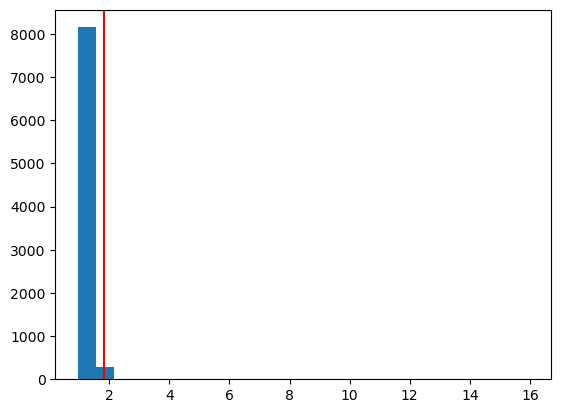

In [31]:
plt.hist(clf.decision_function(X), bins=25)
plt.axvline(np.min(clf.decision_function(X)[np.where(outliers==1)]), c='r')

#plt.savefig('./img/Outlier Detection/LOF_artists_histogram.png', dpi=300, bbox_inches='tight')

plt.show()

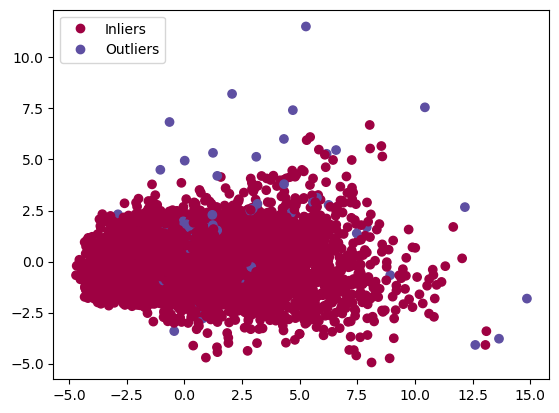

In [33]:
pca = PCA(n_components=2)
pca_data = pd.DataFrame(pca.fit_transform(X), columns=['PC1', 'PC2'])
pca_data['outlier score'] = pd.Categorical(outliers)

fig = plt.figure()
ax = fig.add_subplot()

scatter = ax.scatter(pca_data['PC1'],
                     pca_data['PC2'],
                     c=pca_data['outlier score'],
                     cmap='Spectral')

handles, labels = scatter.legend_elements()
plt.legend(handles, ['Inliers', 'Outliers'], loc='upper left')

#plt.savefig('./img/Outlier Detection/LOF_artists_PCA.png', dpi=300, bbox_inches='tight')

plt.show()

In [37]:
df['lof'].describe()

count    8460.000000
mean        0.009811
std         0.098569
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: lof, dtype: float64

In [42]:
df_out=df[df['lof']==1]
df_out

,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii,lof
59,1.891137,-0.820524,1.119982,1.485392,1.642694,1.066269,2.717543,16.823357,1.032039,-0.341993,1.493563,-0.556933,0.118269,2.182005,0.020963,0.498323,-0.352442,-0.153513,2.0,1
180,-1.186243,1.218734,-1.021966,-0.830673,-0.947190,-2.295245,-0.999571,-0.289581,1.770617,-0.686730,-0.933083,6.931916,-0.164988,-0.639429,-1.159717,-1.264876,0.209956,-1.205336,0.0,1
319,-1.186243,-0.820524,-1.072481,-1.667029,-1.267934,6.074239,-0.802428,-0.289581,-1.060599,-1.364687,-0.933083,-1.067328,-0.213255,-1.134802,-1.035222,-1.264876,-1.397926,-1.455736,0.0,1
431,-0.906481,-0.820524,-0.789637,-0.702002,-0.803574,3.192942,2.112432,-0.236957,4.724929,-0.783917,0.280240,0.783306,-0.102769,-0.710429,-0.672357,0.498323,-0.636205,-0.682354,0.0,1
489,1.891137,-0.820524,3.464803,1.678397,3.552793,3.844664,1.247987,5.827033,3.321630,4.385327,2.706886,2.658890,1.138110,3.066769,3.110291,0.498323,5.521929,5.508395,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7845,-0.906481,-0.820524,2.645943,-0.889861,0.411426,-0.906047,2.414987,2.111339,0.293461,-0.825323,1.493563,0.981086,0.085749,0.675721,-0.234428,2.261521,-0.547415,-0.044967,1.0,1
7968,0.772090,-0.820524,-0.366238,0.359527,-0.084930,-0.631638,-0.091903,-0.637742,-0.198925,0.533440,1.493563,-0.360841,0.271612,-1.780139,3.091484,0.498323,-1.827961,0.483991,0.0,1
8129,-0.346958,-0.820524,0.884833,0.022411,0.347429,-1.231909,-0.239970,-0.362028,-0.198925,6.677649,-2.146406,2.825657,0.165890,0.116550,0.644236,-1.264876,1.167225,0.446408,1.0,1
8236,-0.626720,-0.820524,-0.443236,0.160088,-0.233812,0.397397,-0.091903,-0.304934,0.047268,-0.322298,-0.933083,-0.006709,-0.086097,-1.868057,2.885845,0.498323,-1.939919,-0.468599,0.0,1


In [45]:
list_out=df_out.index.values.tolist()
list(list_out) 

[59,
 180,
 319,
 431,
 489,
 583,
 617,
 825,
 872,
 882,
 921,
 994,
 1287,
 1762,
 2027,
 2033,
 2039,
 2112,
 2113,
 2350,
 2443,
 2717,
 2738,
 2809,
 2854,
 3017,
 3205,
 3270,
 3471,
 3511,
 3524,
 3613,
 3688,
 3791,
 3818,
 4092,
 4139,
 4152,
 4230,
 4264,
 4385,
 4406,
 4469,
 4576,
 4588,
 4837,
 4881,
 5097,
 5193,
 5221,
 5283,
 5285,
 5383,
 5448,
 5543,
 5615,
 5664,
 5811,
 5866,
 6010,
 6107,
 6273,
 6406,
 6496,
 6756,
 6763,
 6767,
 6803,
 6865,
 6878,
 7151,
 7224,
 7304,
 7442,
 7655,
 7678,
 7704,
 7764,
 7845,
 7968,
 8129,
 8236,
 8288]

In [43]:
file_path = "../1.DATASET/CMI_FINAL.csv"
df_original=pd.read_csv(file_path)

In [47]:
df_original[df_original['id'].isin(list_out)]

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_BMR,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
59,59,17,0,24.446886,68.00,160.800000,95.000000,47.000000,115.100000,10.50,1094.350000,4.0,3.502280,2298.130000,139.225600,21.574400,2.0,25.752900,42.541600,2.0
180,180,6,1,14.791120,50.00,52.600000,62.333333,4.000000,18.613018,12.00,1020.350000,2.0,22.435300,1530.520000,50.943230,1.656770,1.0,32.662300,27.440500,0.0
319,319,6,0,14.563403,43.50,39.200000,143.666667,6.280570,18.613018,6.25,874.822000,2.0,2.211920,1399.720000,35.443050,3.756950,1.0,12.908500,23.845500,0.0
431,431,7,0,15.838447,51.00,58.600000,115.666667,40.000000,18.909726,18.00,999.488000,3.0,6.890620,1699.130000,48.721650,9.878350,2.0,22.266700,34.949000,0.0
489,489,17,0,35.017194,69.50,240.600000,122.000000,30.000000,53.100000,15.15,2109.100000,5.0,11.632400,5061.840000,166.909800,73.690200,2.0,97.923100,123.830000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7845,7845,7,0,31.325825,49.54,109.360174,75.833333,43.500000,32.150000,9.00,990.600000,4.0,7.390640,2210.002693,92.094127,17.266047,3.0,23.357540,44.100000,1.0
7968,7968,13,0,17.747100,59.25,88.623475,78.500000,14.500000,16.650000,8.00,1282.267397,4.0,3.998032,2713.680000,15.250529,73.372946,2.0,7.625265,51.694288,0.0
8129,8129,9,0,23.386850,56.63,106.686514,72.666667,12.787145,18.204545,8.00,2601.161949,1.0,12.054014,2427.179740,74.597730,32.088784,1.0,44.422934,51.154704,1.0
8236,8236,8,0,17.400000,57.70,82.403479,88.500000,14.500000,18.526452,8.50,1098.577544,2.0,4.893336,1744.310000,12.499592,69.903888,2.0,6.249796,38.017884,0.0


## PROFF

In [18]:
clf = LOF(contamination=0.01, n_neighbors=256, metric='euclidean', n_jobs=-1)

In [ ]:
clf.fit(X)
outliers = clf.predict(X)
np.unique(outliers, return_counts=True)

In [9]:
clf = LocalOutlierFactor(n_neighbors=2, novelty=True)
clf.fit(X_train)

LocalOutlierFactor(n_neighbors=2, novelty=True)

In [10]:
y_pred = clf.predict(X_test)

In [11]:
clf = LocalOutlierFactor(n_neighbors=2) # , novelty=True
y_pred = clf.fit_predict(X)
np.unique(y_pred, return_counts=True)

(array([-1,  1]), array([ 403, 8057], dtype=int64))

negative_outlier_factor_

The opposite LOF of the training samples. The higher, the more normal. Inliers tend to have a LOF score close to 1 (negative_outlier_factor_ close to -1), while outliers tend to have a larger LOF score.

The local outlier factor (LOF) of a sample captures its supposed ‘degree of abnormality’. It is the average of the ratio of the local reachability density of a sample and those of its k-nearest neighbors.

In [12]:
clf.negative_outlier_factor_

array([-1.        , -1.        , -1.        , ..., -1.21202403,
       -1.13868035, -1.03423547])

In [13]:
np.unique(outliers, return_counts=True)

NameError: name 'outliers' is not defined

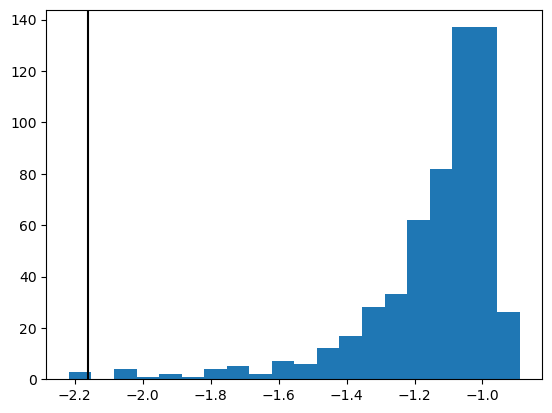

In [ ]:
plt.hist(clf.negative_outlier_factor_, bins=20)
plt.axvline(np.min(clf.negative_outlier_factor_[np.where(outliers==1)]), c='k')
plt.show()

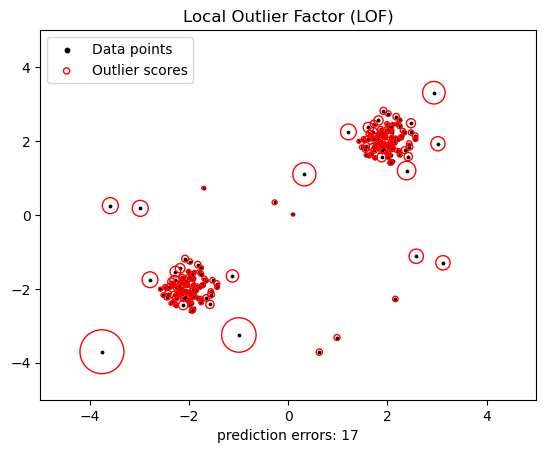

In [ ]:
np.random.seed(42)

# Generate train data
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Generate some outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
Xa = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)
ground_truth = np.ones(len(Xa), dtype=int)
ground_truth[-n_outliers:] = -1

# fit the model for outlier detection (default)
clf = LocalOutlierFactor(n_neighbors=3, contamination=0.01)
# use fit_predict to compute the predicted labels of the training samples
# (when LOF is used for outlier detection, the estimator has no predict,
# decision_function and score_samples methods).
y_pred = clf.fit_predict(Xa)
n_errors = (y_pred != ground_truth).sum()
X_scores = clf.negative_outlier_factor_

plt.title("Local Outlier Factor (LOF)")
plt.scatter(Xa[:, 0], Xa[:, 1], color='k', s=3., label='Data points')
# plot circles with radius proportional to the outlier scores
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
plt.scatter(Xa[:, 0], Xa[:, 1], s=1000 * radius, edgecolors='r',
            facecolors='none', label='Outlier scores')
plt.axis('tight')
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.xlabel("prediction errors: %d" % (n_errors))
legend = plt.legend(loc='upper left')
legend.legend_handles[0]._sizes = [10]
legend.legend_handles[1]._sizes = [20]
plt.show()